# Block 14 — Daily Correlation + VIX Systemic-Risk Overlay

This is an **exploratory extension** to the frozen research programme. Blocks 1–13 are not altered.

The weekly sector engine continues to determine **what to own**. Block 14 adds a faster daily layer determining **how much aggregate equity exposure to carry** when diversification collapses.

**Canonical specification fixed before inspection**
- Weekly sector-selection/state engine: unchanged
- Daily systemic-risk monitoring
- 20-trading-day rolling average pairwise correlation across the 11 sector ETFs
- Correlation threshold: **0.70**
- VIX stress threshold: **25**
- Extreme VIX threshold: **35**
- Equity exposure: **100% normal / 50% stress / 25% extreme stress**
- Residual allocation: cash, assumed 0% return
- Daily close information becomes actionable only on the **next U.S. trading session**
- No optimization of the existing signal parameters

Stress requires **both** high sector correlation and elevated VIX. A predeclared robustness grid tests 20/60-day correlation windows, correlation thresholds 0.60/0.70/0.80, and VIX thresholds 20/25/30 without selecting a new optimum ex post.


In [1]:
# ============================================================
# BLOCK 14.1 — ENVIRONMENT, DRIVE & PROJECT PATHS
# ============================================================
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

PROJECT_ROOT = Path(r"/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation")
if not PROJECT_ROOT.exists():
    alt = Path(r"/content/drive/MyDrive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation")
    if alt.exists():
        PROJECT_ROOT = alt
if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f"Project root not found:\n{PROJECT_ROOT}")

OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MANIFEST_DIR = PROJECT_ROOT / "manifests"
for p in [OUTPUT_DIR,TABLE_DIR,FIGURE_DIR,MANIFEST_DIR]:
    p.mkdir(parents=True,exist_ok=True)

SECTOR_COLS=["XLC","XLY","XLP","XLE","XLF","XLV","XLI","XLK","XLB","XLRE","XLU"]
BENCHMARK="SPY"
print("Project root:",PROJECT_ROOT)


Mounted at /content/drive
Project root: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation


In [2]:
# ============================================================
# BLOCK 14.2 — ROBUST FILE RESOLUTION
# ============================================================
def load_json(path):
    with open(path,"r",encoding="utf-8") as f: return json.load(f)

def manifest_paths():
    found=[]
    for mf in MANIFEST_DIR.glob("*.json"):
        try: obj=load_json(mf)
        except Exception: continue
        def walk(x):
            if isinstance(x,dict):
                for v in x.values(): walk(v)
            elif isinstance(x,list):
                for v in x: walk(v)
            elif isinstance(x,str):
                p=Path(x)
                if p.suffix.lower() in {".parquet",".csv",".json"}: found.append(p)
        walk(obj)
    return found
MANIFEST_PATHS=manifest_paths()

def resolve_file(exact_names=(),patterns=(),required=True,label="file"):
    for p in MANIFEST_PATHS:
        if p.name in exact_names and p.exists(): return p
    for name in exact_names:
        hits=list(PROJECT_ROOT.rglob(name))
        if hits: return hits[0]
    for pat in patterns:
        hits=list(PROJECT_ROOT.rglob(pat))
        if hits: return hits[0]
    if required:
        raise FileNotFoundError(f"Could not resolve {label}.\nExact={list(exact_names)}\nPatterns={list(patterns)}")
    return None

DAILY_CLOSE_PATH=resolve_file(
    ["daily_adjusted_close.parquet","daily_adjusted_closes.parquet","daily_prices_adjusted_close.parquet"],
    ["*daily*adjusted*close*.parquet","*daily*close*.parquet"],label="Block 2 daily adjusted closes")
STATE_WEIGHT_PATH=resolve_file(
    ["weekly_state_dependent_target_weights.parquet"],
    ["*state*dependent*target*weights*.parquet"],label="canonical state-dependent target weights")
CALENDAR_PATH=resolve_file(
    ["weekly_signal_execution_calendar.parquet"],
    ["*signal*execution*calendar*.parquet"],label="weekly signal/execution calendar")

print("Daily close:",DAILY_CLOSE_PATH)
print("State weights:",STATE_WEIGHT_PATH)
print("Calendar:",CALENDAR_PATH)


Daily close: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/daily_adjusted_close_12_assets.parquet
State weights: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/weekly_state_dependent_target_weights.parquet
Calendar: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/weekly_signal_execution_calendar.parquet


In [3]:
# ============================================================
# BLOCK 14.3 — LOAD & NORMALIZE INPUTS
# ============================================================
daily_close=pd.read_parquet(DAILY_CLOSE_PATH).copy()
state_weights=pd.read_parquet(STATE_WEIGHT_PATH).copy()
calendar=pd.read_parquet(CALENDAR_PATH).copy()

if not isinstance(daily_close.index,pd.DatetimeIndex):
    dc=[c for c in daily_close.columns if str(c).lower() in {"date","datetime","timestamp"}]
    if not dc: raise KeyError("Could not identify daily-close date index.")
    daily_close[dc[0]]=pd.to_datetime(daily_close[dc[0]])
    daily_close=daily_close.set_index(dc[0])
daily_close.index=pd.to_datetime(daily_close.index).tz_localize(None)
daily_close=daily_close.sort_index()
missing=[c for c in SECTOR_COLS+[BENCHMARK] if c not in daily_close.columns]
if missing: raise KeyError(f"Missing daily price columns: {missing}")
daily_close=daily_close[SECTOR_COLS+[BENCHMARK]].astype(float)

if not isinstance(state_weights.index,pd.DatetimeIndex):
    dc=[c for c in state_weights.columns if "date" in str(c).lower()]
    if not dc: raise KeyError("Could not identify target-weight date index.")
    state_weights[dc[0]]=pd.to_datetime(state_weights[dc[0]])
    state_weights=state_weights.set_index(dc[0])
state_weights.index=pd.to_datetime(state_weights.index).tz_localize(None)
state_weights=state_weights.sort_index()[SECTOR_COLS].astype(float)

for c in calendar.columns:
    if "date" in str(c).lower():
        try: calendar[c]=pd.to_datetime(calendar[c]).dt.tz_localize(None)
        except Exception: pass

print("Daily price range:",daily_close.index.min(),"to",daily_close.index.max())
print("Weight range:",state_weights.index.min(),"to",state_weights.index.max())
print("Calendar columns:",list(calendar.columns))


Daily price range: 2018-06-19 00:00:00 to 2026-08-28 00:00:00
Weight range: 2019-06-21 00:00:00 to 2026-08-21 00:00:00
Calendar columns: ['signal_observation_date', 'signal_observation_weekday', 'execution_date', 'execution_weekday', 'calendar_days_signal_to_execution']


In [4]:
# ============================================================
# BLOCK 14.4 — MAP WEEKLY TARGETS TO EXECUTION DATES
# ============================================================

# IMPORTANT:
# The canonical weekly target-weight table is Friday-labelled.
# On holiday weeks the actual signal observation may be Thursday, while
# the target-weight index remains the Friday week label.
#
# Block 2's calendar therefore has two distinct concepts:
#   1) calendar INDEX / Friday-labelled signal week
#   2) signal_observation_date / actual market session used for the signal
#
# For mapping weekly target weights to execution dates we must first use
# the Friday-labelled calendar index. Using signal_observation_date alone
# incorrectly fails on holiday weeks.

exe_candidates = [
    "execution_date",
    "rebalance_execution_date",
    "next_execution_date",
    "rebalance_date",
    "trade_date",
]
exe_col = next((c for c in exe_candidates if c in calendar.columns), None)

if exe_col is None:
    raise KeyError(
        "Could not identify execution date in calendar.\n"
        f"Available columns: {list(calendar.columns)}"
    )

calendar_exec = calendar.copy()
calendar_exec.index = pd.to_datetime(calendar_exec.index).tz_localize(None)
calendar_exec[exe_col] = pd.to_datetime(
    calendar_exec[exe_col]
).dt.tz_localize(None)

weight_dates = pd.DatetimeIndex(state_weights.index).tz_localize(None)
execution_dates = pd.DatetimeIndex(
    calendar_exec[exe_col].dropna().unique()
).sort_values()

# CASE 1 — weights are already execution-dated.
execution_overlap = weight_dates.intersection(execution_dates)

if len(execution_overlap) >= max(5, int(0.80 * len(state_weights))):
    weekly_exec_weights = state_weights.copy()
    weekly_exec_weights.index = weight_dates
    mapping_method = "weights_already_execution_dated"

else:
    # CASE 2 — canonical Friday-labelled signal dates.
    index_overlap = weight_dates.intersection(calendar_exec.index)

    if len(index_overlap) >= max(5, int(0.80 * len(state_weights))):
        execution_map = calendar_exec[exe_col]

        tmp = state_weights.copy()
        tmp.index = weight_dates
        tmp["__execution_date__"] = tmp.index.map(execution_map)

        unmapped = tmp["__execution_date__"].isna()

        if unmapped.any():
            print("Dropping non-executable target rows:", int(unmapped.sum()))
            print("Unmapped target labels:", list(tmp.index[unmapped][:10]))
            tmp = tmp.loc[~unmapped].copy()

        weekly_exec_weights = (
            tmp
            .set_index("__execution_date__")[SECTOR_COLS]
            .sort_index()
        )
        mapping_method = "calendar_index_friday_label_to_execution"

    else:
        # CASE 3 — fallback to actual signal-observation date.
        signal_candidates = [
            "signal_observation_date",
            "actual_signal_date",
            "signal_date",
        ]
        sig_col = next(
            (c for c in signal_candidates if c in calendar_exec.columns),
            None,
        )

        if sig_col is None:
            raise KeyError(
                "Could not map target-weight dates to calendar. "
                "Weights match neither execution dates nor the calendar index, "
                "and no signal-observation column is available."
            )

        actual_signal = pd.to_datetime(
            calendar_exec[sig_col]
        ).dt.tz_localize(None)

        actual_map = pd.Series(
            calendar_exec[exe_col].values,
            index=actual_signal.values,
        )
        actual_map = actual_map[~actual_map.index.duplicated(keep="last")]

        tmp = state_weights.copy()
        tmp.index = weight_dates
        tmp["__execution_date__"] = tmp.index.map(actual_map)

        unmapped = tmp["__execution_date__"].isna()

        if unmapped.any():
            print(
                "Dropping non-executable target rows after actual-signal fallback:",
                int(unmapped.sum()),
            )
            print("Unmapped target dates:", list(tmp.index[unmapped][:10]))
            tmp = tmp.loc[~unmapped].copy()

        if tmp.empty:
            raise AssertionError(
                "No target weights could be mapped to execution dates."
            )

        weekly_exec_weights = (
            tmp
            .set_index("__execution_date__")[SECTOR_COLS]
            .sort_index()
        )
        mapping_method = "actual_signal_observation_to_execution"

# FINAL NORMALIZATION / AUDIT
weekly_exec_weights.index = pd.to_datetime(
    weekly_exec_weights.index
).tz_localize(None)
weekly_exec_weights.index.name = "execution_date"

if weekly_exec_weights.index.duplicated().any():
    dup_dates = weekly_exec_weights.index[
        weekly_exec_weights.index.duplicated(keep=False)
    ].unique()

    for d in dup_dates:
        rows = weekly_exec_weights.loc[[d]]
        if len(rows.drop_duplicates()) > 1:
            raise AssertionError(
                f"Conflicting target weights mapped to execution date {d}."
            )

    weekly_exec_weights = weekly_exec_weights[
        ~weekly_exec_weights.index.duplicated(keep="last")
    ]

if weekly_exec_weights.empty:
    raise AssertionError("No executable weekly target weights remain.")

if not np.allclose(
    weekly_exec_weights.sum(axis=1).values,
    1.0,
    atol=1e-8,
):
    bad = weekly_exec_weights.sum(axis=1)
    bad = bad.loc[~np.isclose(bad, 1.0, atol=1e-8)]
    raise AssertionError(
        "Weekly weights do not sum to one.\n"
        f"First bad rows:\n{bad.head()}"
    )

print("Mapping method:", mapping_method)
print("Execution targets:", len(weekly_exec_weights))
print("First execution:", weekly_exec_weights.index.min())
print("Last execution:", weekly_exec_weights.index.max())
print("All target weights sum to 1: True")


Mapping method: calendar_index_friday_label_to_execution
Execution targets: 375
First execution: 2019-06-24 00:00:00
Last execution: 2026-08-24 00:00:00
All target weights sum to 1: True


In [5]:
# ============================================================
# BLOCK 14.5 — DOWNLOAD DAILY VIX
# ============================================================
try:
    import yfinance as yf
except ImportError:
    !pip -q install yfinance
    import yfinance as yf

start=daily_close.index.min()-pd.Timedelta(days=90)
end=daily_close.index.max()+pd.Timedelta(days=5)
raw=yf.download("^VIX",start=start.strftime("%Y-%m-%d"),end=end.strftime("%Y-%m-%d"),
                auto_adjust=False,progress=False)
if raw.empty: raise RuntimeError("VIX download returned no data.")

if isinstance(raw.columns,pd.MultiIndex):
    cols=[c for c in raw.columns if c[0]=="Close"]
    vix=raw[cols[0]].copy()
else:
    vix=raw["Close"].copy()
vix.index=pd.to_datetime(vix.index).tz_localize(None)
vix=vix.astype(float).rename("VIX").sort_index()
VIX_PATH=OUTPUT_DIR/"daily_vix_close.parquet"
vix.to_frame().to_parquet(VIX_PATH)
print("VIX:",vix.index.min(),"to",vix.index.max(),"; n =",len(vix))


VIX: 2018-03-21 00:00:00 to 2026-08-28 00:00:00 ; n = 2123


In [6]:
# ============================================================
# BLOCK 14.6 — DAILY CROSS-SECTOR CORRELATION
# ============================================================
sector_daily_returns=daily_close[SECTOR_COLS].pct_change()

def rolling_average_pairwise_corr(returns,window):
    vals=[]
    for i in range(len(returns)):
        if i+1<window:
            vals.append(np.nan); continue
        corr=returns.iloc[i-window+1:i+1].corr().values
        upper=corr[np.triu_indices_from(corr,k=1)]
        vals.append(np.nanmean(upper))
    return pd.Series(vals,index=returns.index,name=f"avg_pairwise_corr_{window}d")

corr20=rolling_average_pairwise_corr(sector_daily_returns,20)
corr60=rolling_average_pairwise_corr(sector_daily_returns,60)
risk_data=pd.concat([corr20,corr60,vix],axis=1).reindex(daily_close.index)
risk_data["VIX"]=risk_data["VIX"].ffill()

RISK_DATA_PATH=OUTPUT_DIR/"daily_sector_correlation_vix.parquet"
risk_data.to_parquet(RISK_DATA_PATH)
display(risk_data.tail())


,avg_pairwise_corr_20d,avg_pairwise_corr_60d,VIX
Date,,,
2026-08-24,0.115086,0.133661,15.85
2026-08-25,0.110189,0.131435,15.45
2026-08-26,0.082875,0.128286,15.21
2026-08-27,0.125175,0.135450,14.51
2026-08-28,0.145747,0.134928,14.43


In [7]:
# ============================================================
# BLOCK 14.7 — CANONICAL OVERLAY & NEXT-SESSION TIMING
# ============================================================
CANONICAL_CORR_WINDOW=20
CANONICAL_CORR_THRESHOLD=.70
CANONICAL_VIX_THRESHOLD=25.0
EXTREME_VIX_THRESHOLD=35.0
NORMAL_EXPOSURE=1.00
STRESS_EXPOSURE=.50
EXTREME_EXPOSURE=.25

corr_col=f"avg_pairwise_corr_{CANONICAL_CORR_WINDOW}d"
signal=pd.DataFrame(index=risk_data.index)
signal["corr"]=risk_data[corr_col]
signal["vix"]=risk_data["VIX"]
signal["stress_close"]=(signal["corr"]>=CANONICAL_CORR_THRESHOLD)&(signal["vix"]>=CANONICAL_VIX_THRESHOLD)
signal["extreme_stress_close"]=(signal["corr"]>=CANONICAL_CORR_THRESHOLD)&(signal["vix"]>=EXTREME_VIX_THRESHOLD)

signal["target_equity_exposure_close"]=NORMAL_EXPOSURE
signal.loc[signal["stress_close"],"target_equity_exposure_close"]=STRESS_EXPOSURE
signal.loc[signal["extreme_stress_close"],"target_equity_exposure_close"]=EXTREME_EXPOSURE

# t-close information is applied only to the next trading session's return.
signal["realized_equity_exposure"]=signal["target_equity_exposure_close"].shift(1)

print("Stress closes:",int(signal["stress_close"].sum()))
print("Extreme-stress closes:",int(signal["extreme_stress_close"].sum()))
print("Realized exposures:",sorted(signal["realized_equity_exposure"].dropna().unique()))


Stress closes: 196
Extreme-stress closes: 54
Realized exposures: [np.float64(0.25), np.float64(0.5), np.float64(1.0)]


In [8]:
# ============================================================
# BLOCK 14.8 — DAILY RETURN ENGINE
# ============================================================
daily_dates=daily_close.index

# Weekly target set at execution close; it earns from the next close-to-close interval.
exec_w=weekly_exec_weights.reindex(daily_dates).ffill()
base_weights_daily=exec_w.shift(1)

sector_ret=daily_close[SECTOR_COLS].pct_change()
base_daily_return=(base_weights_daily*sector_ret).sum(axis=1,min_count=1)
base_daily_return.name="State_Dependent_Daily_Reconstructed"

overlay_exposure=signal["realized_equity_exposure"].reindex(daily_dates)
overlay_daily_return=(base_daily_return*overlay_exposure).rename("State_Dependent_VIX_Corr_Overlay")
spy_daily_return=daily_close[BENCHMARK].pct_change().rename("SPY")

daily_comparison=pd.concat([spy_daily_return,base_daily_return,overlay_daily_return],axis=1).dropna()
first_exec=weekly_exec_weights.index.min()
last_exec=weekly_exec_weights.index.max()
daily_comparison=daily_comparison.loc[(daily_comparison.index>first_exec)&(daily_comparison.index<=last_exec)]

print("Comparison:",daily_comparison.index.min(),"to",daily_comparison.index.max())
print("Observations:",len(daily_comparison))


Comparison: 2019-06-25 00:00:00 to 2026-08-24 00:00:00
Observations: 1801


In [9]:
# ============================================================
# BLOCK 14.9 — PERFORMANCE METRICS
# ============================================================
PPY=252

def max_drawdown(r):
    w=(1+r.dropna()).cumprod()
    return (w/w.cummax()-1).min()

def perf_stats(r):
    r=r.dropna()
    w=(1+r).cumprod()
    years=(r.index[-1]-r.index[0]).days/365.2425
    cagr=w.iloc[-1]**(1/years)-1
    vol=r.std(ddof=1)*np.sqrt(PPY)
    sharpe=r.mean()/r.std(ddof=1)*np.sqrt(PPY) if r.std(ddof=1)>0 else np.nan
    downside=r[r<0].std(ddof=1)*np.sqrt(PPY)
    sortino=(r.mean()*PPY)/downside if downside>0 else np.nan
    mdd=max_drawdown(r)
    return pd.Series({"Terminal_Wealth":w.iloc[-1],"CAGR":cagr,"Annualized_Volatility":vol,
                      "Sharpe":sharpe,"Sortino":sortino,"Max_Drawdown":mdd,
                      "Calmar":cagr/abs(mdd) if mdd<0 else np.nan})

performance=daily_comparison.apply(perf_stats).T
performance.loc["State_Dependent_VIX_Corr_Overlay","Stress_Day_Fraction"]=(overlay_exposure.reindex(daily_comparison.index)<1).mean()
performance.loc["State_Dependent_VIX_Corr_Overlay","Average_Equity_Exposure"]=overlay_exposure.reindex(daily_comparison.index).mean()
display(performance)


,Terminal_Wealth,CAGR,Annualized_Volatility,Sharpe,Sortino,Max_Drawdown,Calmar,Stress_Day_Fraction,Average_Equity_Exposure
SPY,2.879664,0.159066,0.196955,0.850332,1.045185,-0.337173,0.471764,NaN,NaN
State_Dependent_Daily_Reconstructed,2.563908,0.140430,0.182244,0.814622,0.967331,-0.352421,0.398472,NaN,NaN
State_Dependent_VIX_Corr_Overlay,2.413896,0.130874,0.132552,0.996949,1.295964,-0.163955,0.798231,0.106052,0.939478


In [10]:
# ============================================================
# BLOCK 14.10 — TURNOVER & COST SENSITIVITY
# ============================================================
overlay_weights=base_weights_daily.mul(overlay_exposure,axis=0)
overlay_cash=1-overlay_exposure
base_cash=pd.Series(0.0,index=base_weights_daily.index)

def one_way_turnover(weights,cash):
    x=weights.copy()
    x["CASH"]=cash
    return .5*x.diff().abs().sum(axis=1)

base_turnover=one_way_turnover(base_weights_daily,base_cash)
overlay_turnover=one_way_turnover(overlay_weights,overlay_cash)

rows=[]
for bps in [0,5,10,20]:
    r=overlay_daily_return-overlay_turnover*(bps/10000)
    s=perf_stats(r.loc[daily_comparison.index])
    s["Cost_bps"]=bps
    s["Annualized_OneWay_Turnover"]=overlay_turnover.loc[daily_comparison.index].mean()*PPY
    rows.append(s)
cost_sensitivity=pd.DataFrame(rows).set_index("Cost_bps")
display(cost_sensitivity)


,Terminal_Wealth,CAGR,Annualized_Volatility,Sharpe,Sortino,Max_Drawdown,Calmar,Annualized_OneWay_Turnover
Cost_bps,,,,,,,,
0.0,2.413896,0.130874,0.132552,0.996949,1.295964,-0.163955,0.798231,3.771526
5.0,2.381574,0.128748,0.132561,0.982658,1.277035,-0.164700,0.781713,3.771526
10.0,2.349678,0.126626,0.132572,0.968348,1.258126,-0.165445,0.765368,3.771526
20.0,2.287142,0.122393,0.132604,0.939674,1.220200,-0.166933,0.733186,3.771526


In [11]:
# ============================================================
# BLOCK 14.11 — PREDECLARED ROBUSTNESS GRID
# ============================================================
CORR_WINDOWS=[20,60]
CORR_THRESHOLDS=[.60,.70,.80]
VIX_THRESHOLDS=[20.,25.,30.]
rows=[]

for window in CORR_WINDOWS:
    c=risk_data[f"avg_pairwise_corr_{window}d"]
    for ct in CORR_THRESHOLDS:
        for vt in VIX_THRESHOLDS:
            target=pd.Series(NORMAL_EXPOSURE,index=risk_data.index,dtype=float)
            stress=(c>=ct)&(risk_data["VIX"]>=vt)
            extreme=(c>=ct)&(risk_data["VIX"]>=EXTREME_VIX_THRESHOLD)
            target.loc[stress]=STRESS_EXPOSURE
            target.loc[extreme]=EXTREME_EXPOSURE
            realized=target.shift(1).reindex(daily_dates)
            r=(base_daily_return*realized).loc[daily_comparison.index]
            s=perf_stats(r)
            rows.append({"Corr_Window":window,"Corr_Threshold":ct,"VIX_Threshold":vt,
                         "Terminal_Wealth":s["Terminal_Wealth"],"CAGR":s["CAGR"],
                         "Sharpe":s["Sharpe"],"Sortino":s["Sortino"],
                         "Max_Drawdown":s["Max_Drawdown"],"Calmar":s["Calmar"],
                         "Stress_Fraction":(realized.loc[daily_comparison.index]<1).mean(),
                         "Average_Exposure":realized.loc[daily_comparison.index].mean(),
                         "Is_Canonical":window==20 and ct==.70 and vt==25.})
robustness=pd.DataFrame(rows)
display(robustness)


,Corr_Window,Corr_Threshold,VIX_Threshold,Terminal_Wealth,CAGR,Sharpe,Sortino,Max_Drawdown,Calmar,Stress_Fraction,Average_Exposure,Is_Canonical
0,20,0.6,20.0,2.230482,0.118470,0.977256,1.290128,-0.151142,0.783834,0.188784,0.897973,False
1,20,0.6,25.0,2.414083,0.130886,1.035200,1.378415,-0.151142,0.865983,0.138812,0.922959,False
2,20,0.6,30.0,2.258430,0.120416,0.889135,1.140219,-0.190136,0.633313,0.064964,0.959883,False
3,20,0.7,20.0,2.377718,0.128493,0.991804,1.278667,-0.163955,0.783709,0.134370,0.925319,False
4,20,0.7,25.0,2.413896,0.130874,0.996949,1.295964,-0.163955,0.798231,0.106052,0.939478,True
5,20,0.7,30.0,2.317787,0.124480,0.913230,1.174381,-0.187705,0.663168,0.061632,0.961688,False
6,20,0.8,20.0,2.561932,0.140307,0.971189,1.287780,-0.193541,0.724947,0.045530,0.971544,False
7,20,0.8,25.0,2.590502,0.142074,0.981293,1.302423,-0.193541,0.734073,0.040533,0.974042,False
8,20,0.8,30.0,2.600472,0.142686,0.982150,1.304793,-0.193541,0.737237,0.033315,0.977651,False
9,60,0.6,20.0,2.139137,0.111962,0.930980,1.213153,-0.163955,0.682880,0.205997,0.889367,False


In [12]:
# ============================================================
# BLOCK 14.12 — REGIME DIAGNOSTICS
# ============================================================
diag=pd.concat([risk_data,signal[["stress_close","extreme_stress_close",
    "target_equity_exposure_close","realized_equity_exposure"]],daily_comparison],axis=1)
top_vix=diag.nlargest(20,"VIX")
top_corr=diag.nlargest(20,corr_col)
annual=pd.DataFrame({
    "Average_Correlation":diag[corr_col].resample("YE").mean(),
    "Average_VIX":diag["VIX"].resample("YE").mean(),
    "Stress_Day_Fraction":diag["stress_close"].resample("YE").mean(),
    "Average_Equity_Exposure":diag["realized_equity_exposure"].resample("YE").mean()
})
display(annual)


,Average_Correlation,Average_VIX,Stress_Day_Fraction,Average_Equity_Exposure
Date,,,,
2018-12-31,0.421932,16.851926,0.029630,0.988806
2019-12-31,0.463896,15.387857,0.003968,0.996032
2020-12-31,0.616580,29.251304,0.379447,0.761858
2021-12-31,0.447160,19.656389,0.000000,1.000000
2022-12-31,0.618034,25.623904,0.318725,0.840637
2023-12-31,0.505497,16.870040,0.000000,1.000000
2024-12-31,0.406912,15.607579,0.000000,1.000000
2025-12-31,0.444989,18.961120,0.060000,0.965000
2026-12-31,0.226807,18.608424,0.000000,1.000000


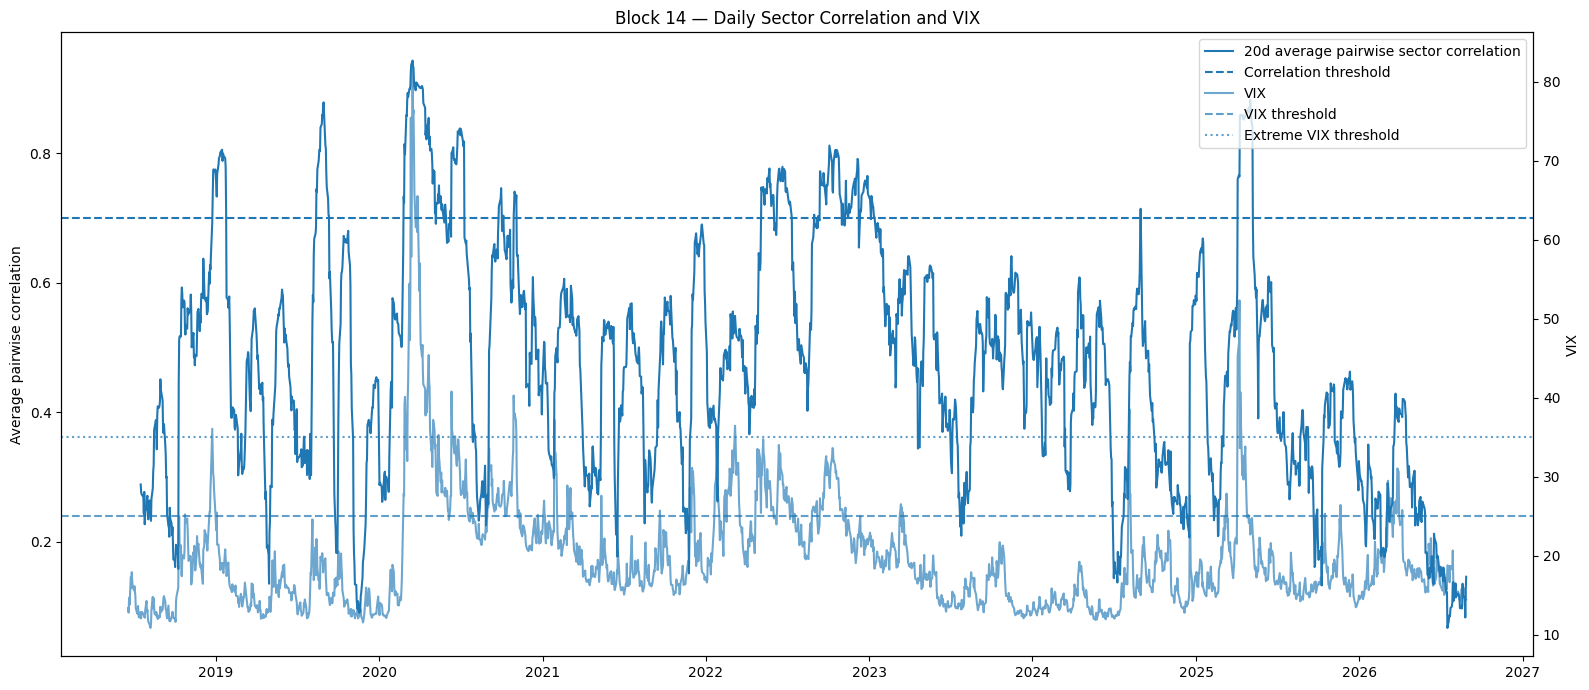

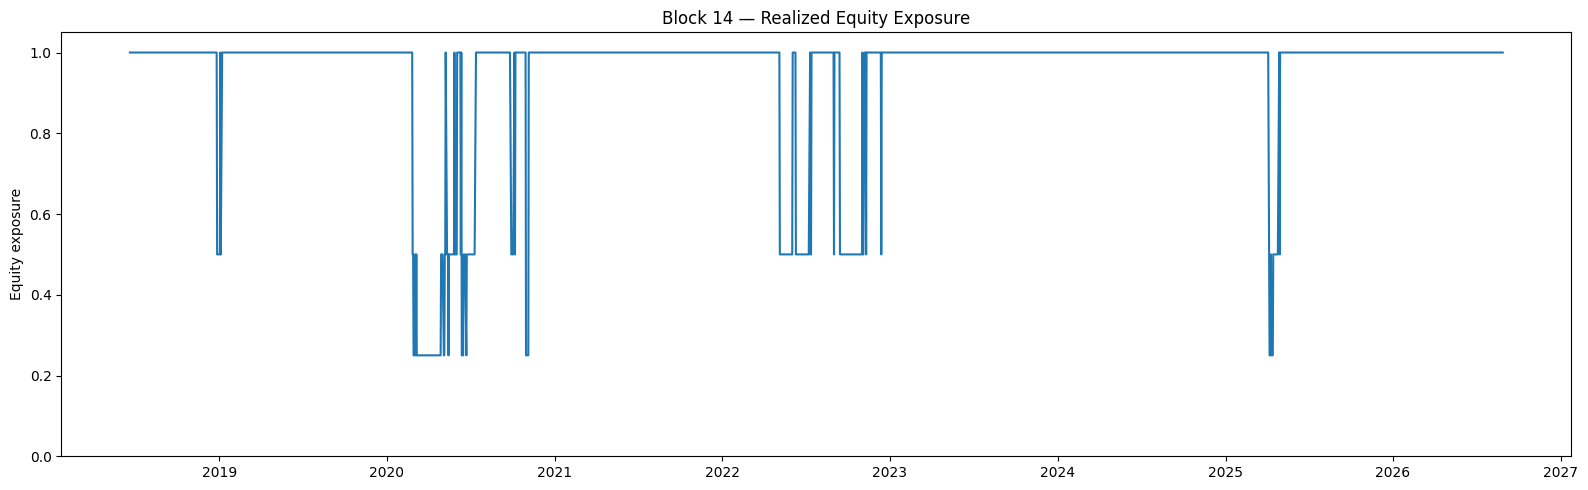

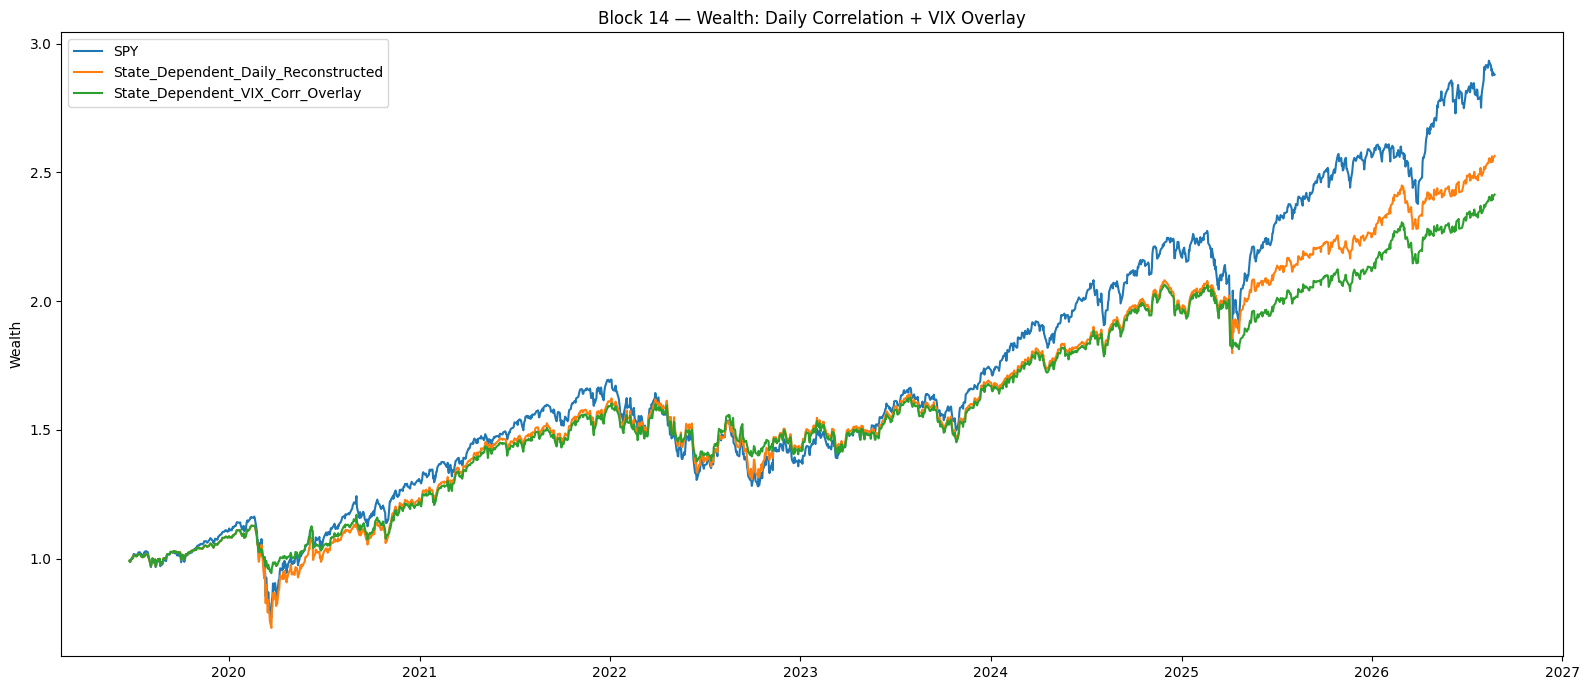

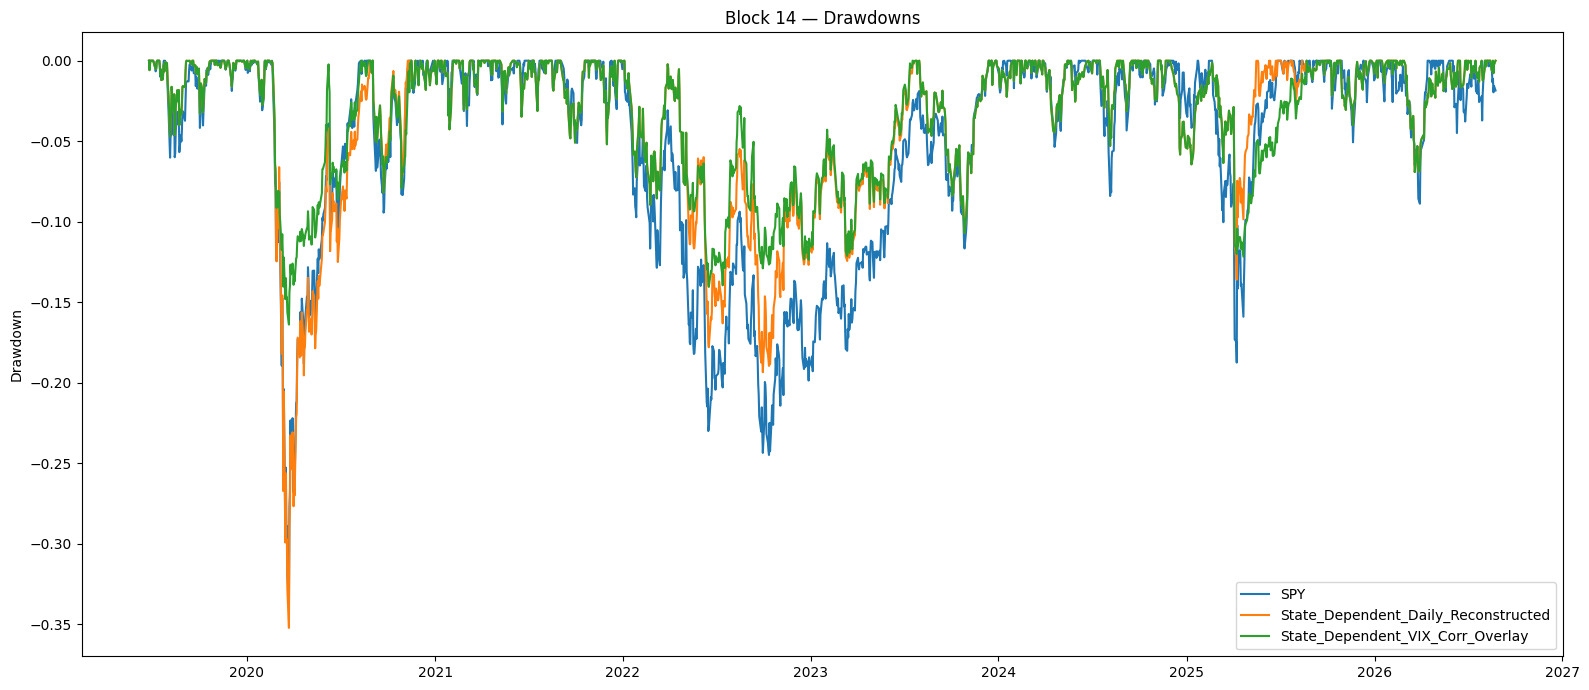

In [13]:
# ============================================================
# BLOCK 14.13 — FIGURES
# ============================================================
fig,ax1=plt.subplots(figsize=(16,7))
ax1.plot(risk_data.index,risk_data[corr_col],label="20d average pairwise sector correlation")
ax1.axhline(CANONICAL_CORR_THRESHOLD,linestyle="--",label="Correlation threshold")
ax1.set_ylabel("Average pairwise correlation")
ax1.set_title("Block 14 — Daily Sector Correlation and VIX")
ax2=ax1.twinx()
ax2.plot(risk_data.index,risk_data["VIX"],alpha=.65,label="VIX")
ax2.axhline(CANONICAL_VIX_THRESHOLD,linestyle="--",alpha=.7,label="VIX threshold")
ax2.axhline(EXTREME_VIX_THRESHOLD,linestyle=":",alpha=.7,label="Extreme VIX threshold")
ax2.set_ylabel("VIX")
l1,a1=ax1.get_legend_handles_labels(); l2,a2=ax2.get_legend_handles_labels()
ax1.legend(l1+l2,a1+a2,loc="upper right")
fig.tight_layout(); fig.savefig(FIGURE_DIR/"block_14_daily_correlation_vix.png",dpi=180); plt.show()

fig,ax=plt.subplots(figsize=(16,5))
ax.plot(signal.index,signal["realized_equity_exposure"])
ax.set_title("Block 14 — Realized Equity Exposure"); ax.set_ylabel("Equity exposure"); ax.set_ylim(0,1.05)
fig.tight_layout(); fig.savefig(FIGURE_DIR/"block_14_equity_exposure.png",dpi=180); plt.show()

wealth=(1+daily_comparison).cumprod()
fig,ax=plt.subplots(figsize=(16,7))
for c in wealth.columns: ax.plot(wealth.index,wealth[c],label=c)
ax.set_title("Block 14 — Wealth: Daily Correlation + VIX Overlay"); ax.set_ylabel("Wealth"); ax.legend()
fig.tight_layout(); fig.savefig(FIGURE_DIR/"block_14_wealth.png",dpi=180); plt.show()

dd=wealth.div(wealth.cummax()).sub(1)
fig,ax=plt.subplots(figsize=(16,7))
for c in dd.columns: ax.plot(dd.index,dd[c],label=c)
ax.set_title("Block 14 — Drawdowns"); ax.set_ylabel("Drawdown"); ax.legend()
fig.tight_layout(); fig.savefig(FIGURE_DIR/"block_14_drawdowns.png",dpi=180); plt.show()


In [14]:
# ============================================================
# BLOCK 14.14 — SAVE OUTPUTS & MANIFEST
# ============================================================
PERF_PATH=TABLE_DIR/"block_14_daily_overlay_performance.csv"
COST_PATH=TABLE_DIR/"block_14_cost_sensitivity.csv"
ROBUST_PATH=TABLE_DIR/"block_14_overlay_robustness_grid.csv"
ANNUAL_PATH=TABLE_DIR/"block_14_annual_regime_diagnostics.csv"
TOP_VIX_PATH=TABLE_DIR/"block_14_top_vix_days.csv"
TOP_CORR_PATH=TABLE_DIR/"block_14_top_correlation_days.csv"
SIGNAL_PATH=OUTPUT_DIR/"block_14_daily_overlay_signal.parquet"
RETURNS_PATH=OUTPUT_DIR/"block_14_daily_overlay_returns.parquet"

performance.to_csv(PERF_PATH)
cost_sensitivity.to_csv(COST_PATH)
robustness.to_csv(ROBUST_PATH,index=False)
annual.to_csv(ANNUAL_PATH)
top_vix.to_csv(TOP_VIX_PATH)
top_corr.to_csv(TOP_CORR_PATH)
signal.to_parquet(SIGNAL_PATH)
daily_comparison.to_parquet(RETURNS_PATH)

manifest={
 "block":14,
 "title":"Daily Correlation + VIX Systemic-Risk Overlay",
 "research_extension":True,
 "blocks_1_to_13_altered":False,
 "new_signal_optimization_performed":False,
 "sector_engine_frequency":"WEEKLY",
 "overlay_monitoring_frequency":"DAILY",
 "timing_rule":"DAILY_CLOSE_SIGNAL_EFFECTIVE_NEXT_US_TRADING_SESSION",
 "canonical_specification":{
   "correlation_window_trading_days":20,"correlation_threshold":.70,
   "vix_threshold":25.0,"extreme_vix_threshold":35.0,
   "normal_equity_exposure":1.0,"stress_equity_exposure":.50,
   "extreme_equity_exposure":.25,"cash_return_assumption":0.0},
 "robustness_grid":{"correlation_windows":[20,60],
                    "correlation_thresholds":[.60,.70,.80],
                    "vix_thresholds":[20.,25.,30.]},
 "saved_files":{"daily_vix":str(VIX_PATH),"daily_risk_data":str(RISK_DATA_PATH),
                "performance":str(PERF_PATH),"cost_sensitivity":str(COST_PATH),
                "robustness":str(ROBUST_PATH),"annual_diagnostics":str(ANNUAL_PATH),
                "overlay_signal":str(SIGNAL_PATH),"daily_returns":str(RETURNS_PATH)}
}
MANIFEST_PATH=MANIFEST_DIR/"block_14_daily_correlation_vix_overlay.json"
with open(MANIFEST_PATH,"w",encoding="utf-8") as f: json.dump(manifest,f,indent=2)

status=pd.DataFrame({"Value":[False,False,"DAILY","20 trading days",.70,25.,35.,
                              "100% / 50% / 25%",True,True,True,True]},
 index=["Blocks 1–13 altered","Signal parameters optimized","Overlay monitoring frequency",
        "Canonical correlation window","Canonical correlation threshold","Canonical VIX threshold",
        "Extreme VIX threshold","Exposure ladder","Next-session timing enforced",
        "Robustness grid saved","Cost sensitivity saved","All figures saved"])
display(status)

print("\nBLOCK 14 COMPLETE")
print("Next: assess whether the daily correlation + VIX overlay improves")
print("drawdown control and risk-adjusted returns without sacrificing too much CAGR.")


,Value
Blocks 1–13 altered,False
Signal parameters optimized,False
Overlay monitoring frequency,DAILY
Canonical correlation window,20 trading days
Canonical correlation threshold,0.7
Canonical VIX threshold,25.0
Extreme VIX threshold,35.0
Exposure ladder,100% / 50% / 25%
Next-session timing enforced,True
Robustness grid saved,True



BLOCK 14 COMPLETE
Next: assess whether the daily correlation + VIX overlay improves
drawdown control and risk-adjusted returns without sacrificing too much CAGR.
